# Finite-Difference Playground

Validate one finite-difference C update by comparing stencil weights,
symbolic code, and numerical samples.

Navigation: [Index](../index.ipynb) |
Previous: [Boundary Conditions and Convergence](boundary_conditions_and_convergence.ipynb) |
Next: [Wave Equation and C Code Generation](../3-wave_equation/wave_equation_and_c_codegen.ipynb)

## Learning Goals

- Experiment with one finite-difference derivative.
- Compare exact and numerical derivatives for a simple polynomial.
- Connect stencil coefficients to generated C code.

## Words for This Notebook

- **Playground:** a safe small example where you can change one choice and rerun.
- **Exact derivative:** the derivative computed by algebra.
- **Numerical derivative:** the derivative estimated from grid values.
- **Kernel:** a generated C routine that applies the formula repeatedly on grid data.
- **Stencil:** a fixed weighted sum of nearby grid values.
- **Grid field:** an array value stored on every grid point.
- **Derivative symbol:** a symbolic placeholder that tells NRPy which finite
  difference operator to generate.

Use the code cells actively: first predict what should happen, then run the
cell, then explain the output in plain language. This predict-run-explain
pattern keeps the physics idea connected to the programming details.

## Build and Validate One Finite-Difference Kernel

The fourth-order second-derivative stencil is

$$
\partial_x^2 u_i \approx
\frac{-u_{i-2} + 16u_{i-1} - 30u_i + 16u_{i+1} - u_{i+2}}
{12 \Delta x^2}.
$$

The polynomial `x**4` has exact second derivative `12*x**2`. The stencil
should reproduce it at the sample point used here.

## How the Stencil Becomes Generated C

The generated C example has a few moving parts. This table shows where each
one fits before the code introduces the names.

| Name | Role |
| --- | --- |
| `uu` | Evolved grid field whose values are read at neighboring grid points. |
| `uu_dDD[0][0]` | Symbolic request for the second derivative in coordinate 0. |
| `dDD00` | Finite-difference operator chosen for that derivative. |
| `fd_function...` | Generated helper that applies the stencil weights. |
| `laplacian_x0` | C assignment target for the generated derivative value. |

## Setup: Import SymPy for the Polynomial Test

These imports expose the NRPy and Python tools used in the next steps.

In [1]:
import sympy as sp

## Setup: Import Stencil and Codegen Helpers

These imports expose the NRPy finite-difference and code-writing tools used
below.

In [2]:
import nrpy.c_codegen as ccg
import nrpy.finite_difference as fd
import nrpy.grid as grid
import nrpy.indexedexp as ixp
import nrpy.params as par

## Setup: Clear Playground Grid State

The reset clears tutorial-owned finite-difference helpers and fixes the order
used in the next calculation.

In [3]:
grid.glb_gridfcs_dict.pop("uu", None)
for name in list(fd.FDFunctions_dict):
    if name.startswith("fdD"):
        fd.FDFunctions_dict.pop(name, None)
par.set_parval_from_str("Infrastructure", "BHaH")
par.set_parval_from_str("finite_difference::fd_order", 4)
print("infrastructure:", par.parval_from_str("Infrastructure"))
print("finite-difference order:", par.parval_from_str("finite_difference::fd_order"))
print("tutorial grid field reset:", "uu" not in grid.glb_gridfcs_dict)

infrastructure: BHaH
finite-difference order: 4
tutorial grid field reset: True


## Step 1: Ask NRPy for the Stencil Weights

The printed coefficients should match the formula above. The `dDD00`
operator means a second derivative in the first coordinate direction.

Before running the cell, predict that a fourth-order centered second
derivative will use two neighbors on each side of the center point.

In [4]:
coeffs, stencil = fd.compute_fdcoeffs_fdstencl("dDD00", 4)
offset_weight_pairs = [(point[0], coeff) for coeff, point in zip(coeffs, stencil)]
print("stencil weights:")
for offset, coeff in offset_weight_pairs:
    print(offset, coeff)

stencil weights:
-2 -1/12
-1 4/3
0 -5/2
1 4/3
2 -1/12


## Step 2: Plot Weights by Grid Offset

The signs and symmetry of the weights explain the second derivative: the
center point is compared against nearby points on both sides.

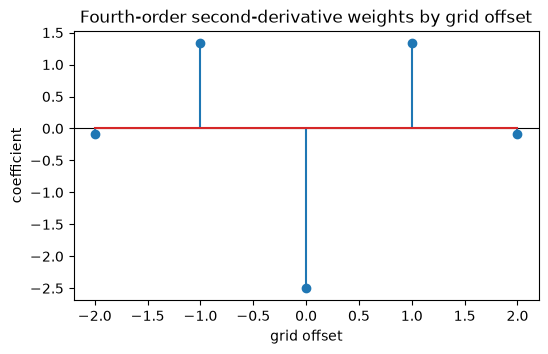

In [5]:
import matplotlib.pyplot as plt


offsets = [point[0] for point in stencil]
numeric_coeffs = [float(coeff) for coeff in coeffs]
plt.figure(figsize=(6, 3.5))
plt.axhline(0.0, color="black", linewidth=0.8)
plt.stem(offsets, numeric_coeffs)
plt.xlabel("grid offset")
plt.ylabel("coefficient")
plt.title("Fourth-order second-derivative weights by grid offset")
plt.show()

## Step 3: Validation Check: Test the Stencil on a Polynomial

The signed offset-to-weight mapping should match the hand formula, and a zero
residual confirms that the stencil reproduces this polynomial derivative.

In [6]:
expected_offset_weight_pairs = [
    (-2, -sp.Rational(1, 12)),
    (-1, sp.Rational(4, 3)),
    (0, -sp.Rational(5, 2)),
    (1, sp.Rational(4, 3)),
    (2, -sp.Rational(1, 12)),
]
if offset_weight_pairs != expected_offset_weight_pairs:
    raise RuntimeError(f"Unexpected stencil mapping: {offset_weight_pairs}")
x = sp.Symbol("x")
x0 = sp.Rational(3, 2)
dx = sp.Rational(1, 5)
stencil_value = sp.simplify(
    sum(
        coeffs[i] * (x0 + stencil[i][0] * dx) ** 4 / dx**2
        for i in range(len(coeffs))
    )
)
exact_value = sp.diff(x**4, x, 2).subs(x, x0)
residual = sp.simplify(stencil_value - exact_value)
print("stencil value:", stencil_value)
print("exact value:", exact_value)
print("residual:", residual)
if residual != 0:
    raise RuntimeError("Expected the stencil residual to vanish.")

stencil value: 27
exact value: 27
residual: 0


## Step 4: Generate and Validate the C Laplacian Assignment

NRPy's stored grid-field list records named fields and their roles in
generated code. The full generated output is printed below. Look for:

- the same coefficient pattern as the displayed stencil;
- reads from neighboring `uu` grid values;
- the assignment target `laplacian_x0`;
- the helper function used for the finite-difference operator.

The checks in the next cell use NRPy metadata for the finite-difference
function and fail if those expected pieces are missing.

In [7]:
uu = grid.register_gridfunctions("uu", group="EVOL")[0]
uu_dDD = ixp.declarerank2("uu_dDD", symmetry="sym01")
generated_laplacian = ccg.c_codegen(
    uu_dDD[0][0],
    "laplacian_x0",
    include_braces=False,
    verbose=False,
    enable_fd_codegen=True,
    enable_fd_functions=True,
)
helper_code = fd.construct_FD_functions_prefunc()
fd_function = fd.FDFunctions_dict.get("dDD00")
if fd_function is None:
    raise RuntimeError(
        "Expected NRPy to register the dDD00 finite-difference function."
    )
if fd_function.operator != "dDD00":
    raise RuntimeError("Expected the generated finite-difference operator to be dDD00.")
if fd_function.fd_order != 4:
    raise RuntimeError("Expected the generated finite-difference order to be 4.")
fd_symbols = {str(symbol): symbol for symbol in fd_function.FDexpr.free_symbols}
expected_fdexpr = fd_symbols["invdxx0"] ** 2 * (
    -sp.Rational(5, 2) * fd_symbols["FDPROTO"]
    + sp.Rational(4, 3)
    * (fd_symbols["FDPROTO_i0m1"] + fd_symbols["FDPROTO_i0p1"])
    - sp.Rational(1, 12)
    * (fd_symbols["FDPROTO_i0m2"] + fd_symbols["FDPROTO_i0p2"])
)
actual_fdexpr = fd_function.FDexpr.xreplace(fd_function.symbol_to_Rational_dict)
fdexpr_residual = sp.simplify(actual_fdexpr - expected_fdexpr)
if fdexpr_residual != 0:
    raise RuntimeError(f"Unexpected generated FD expression: {actual_fdexpr}")
required_generated_identifiers = [
    "uu_i0m2",
    "uu_i0p2",
    fd_function.c_function_name,
    "laplacian_x0",
]
combined_generated_code = generated_laplacian + "\n" + helper_code
missing_identifiers = [
    identifier
    for identifier in required_generated_identifiers
    if identifier not in combined_generated_code
]
if missing_identifiers:
    raise RuntimeError(f"Missing generated-code identifiers: {missing_identifiers}")
print("generated code checks passed")
print("finite-difference helper:", fd_function.c_function_name)
print("finite-difference expression residual:", fdexpr_residual)
print("complete generated C update:")
print(generated_laplacian)
print("complete helper code:")
print(helper_code)

generated code checks passed
finite-difference helper: fd_function_dDD00_fdorder4
finite-difference expression residual: 0
complete generated C update:
/*
 * NRPy-Generated GF Access/FD Code, Step 1 of 2:
 * Read gridfunction(s) from main memory and compute FD stencils as needed.
 */
const REAL uu_i0m2 = in_gfs[IDX4(UUGF, i0-2, i1, i2)];
const REAL uu_i0m1 = in_gfs[IDX4(UUGF, i0-1, i1, i2)];
const REAL uu = in_gfs[IDX4(UUGF, i0, i1, i2)];
const REAL uu_i0p1 = in_gfs[IDX4(UUGF, i0+1, i1, i2)];
const REAL uu_i0p2 = in_gfs[IDX4(UUGF, i0+2, i1, i2)];
const REAL uu_dDD00 = fd_function_dDD00_fdorder4(uu,uu_i0m1,uu_i0m2,uu_i0p1,uu_i0p2,invdxx0);

/*
 * NRPy-Generated GF Access/FD Code, Step 2 of 2:
 * Evaluate SymPy expressions and write to main memory.
 */
laplacian_x0 = uu_dDD00;

complete helper code:
/**
 * Finite difference function for operator dDD00, with FD accuracy order 4.
 */
static NO_INLINE REAL fd_function_dDD00_fdorder4(const REAL FDPROTO, const REAL FDPROTO_i0m1, const REAL FD

The residual check ties the displayed stencil to an exact polynomial
derivative. The generated C update and helper code show the same coefficients
in the form used inside C loops.

## Learning Check

After the notebook works once, change the finite-difference order and explain
how the stencil width changes when you rerun the coefficient cell.

## Continue to Wave-Equation Codegen
- [C Code Generation](../1-intro/c_codegen.ipynb)
- [Finite Differences](../1-intro/finite_difference.ipynb)
- [Wave Equation and C Code Generation](../3-wave_equation/wave_equation_and_c_codegen.ipynb)